# Puzzle Velocity Analysis — Day Nine

*Same question as [day seven](day-seven-analysis.ipynb): is the lccjs microtask estimator any good?*

**Day-nine upgrades (day-eight was skipped):**
- Data source: still SQLite (`~/.lccjs/lccjs.db`) — no pipeline change
- Full re-run on updated dataset (current counts in §0), including 06-04 and 06-05 session data
- 🆕 §2: extended day window (06-04, 06-05 buckets added)
- 🆕 §3: agent roster updated — all agents grew since day-seven
- 🆕 §6: ELDERBERRY task-mix drill-down — re-run on expanded dataset
- All normalization in-memory; DB is never mutated


<details>
<summary><strong>New here? — project orientation (click to expand)</strong></summary>

This notebook analyses the **lccjs puzzle-velocity log** — a per-task time record that tracks how long Claude actually takes to close GitHub issues vs. how long it predicted. Two estimates are recorded per task: **H** (the human's time budget, enforces Yegor's ≤60m hard cap) and **C** (Claude's own forward-looking wall-clock prediction, used for calibration). `c_ratio = c_min / actual_min` — values above 1 mean Claude over-estimated (task finished faster than predicted). **Agents** (APPLE, BANANA, CHERRY, DRAGONFRUIT, ELDERBERRY, FIG, GRAPE) are named Claude sessions, each working an isolated git worktree of the same repo. The goal: understand whether predictions are systematically biased, and whether they improve over time.

</details>

> **Stats vocabulary:** unfamiliar with KW, MWU, bootstrap CI, or Spearman ρ? See [docs/glossary/stats-analysis.md](../docs/glossary/stats-analysis.md) for plain-language explanations of every statistical term used in this notebook.

In [1]:
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(0)
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

In [2]:
DB = Path.home() / ".lccjs" / "lccjs.db"
con = sqlite3.connect(DB)
df = pd.read_sql("SELECT * FROM velocity ORDER BY id", con)
con.close()

# --- In-memory normalization (never touches DB) ---

# Model: collapse long-form stragglers introduced after #314 (skill template lag)
df["model"] = df["model"].replace({
    "claude-sonnet-4-6": "sonnet-4.6",
    "claude-opus-4-8":   "opus-4.8",
})

# TZ: normalize -1000 suffix → -10:00 for fromisoformat compat
for col in ["started_iso", "finished_iso"]:
    df[col] = df[col].str.replace(r"([+-]\d{2})(\d{2})$", r"\1:\2", regex=True)

# Numeric coercion
for c in ["h_min", "c_min", "actual_min"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Derived columns
df["c_ratio"]  = df["c_min"] / df["actual_min"]   # >1 = over-estimate (ran faster)
df["finished"] = pd.to_datetime(df["finished_iso"], errors="coerce", utc=True)
df["hst_day"]  = df["finished"].dt.tz_convert("Etc/GMT+10").dt.date.astype(str)

# Day-nine ceiling: restrict to rows through 2026-06-05 HST so re-execution stays reproducible
df = df[df["hst_day"] <= '2026-06-05'].copy()
df["agent"]    = df["agent"].fillna("").astype(str).str.strip()
df["role"]     = df["role"].fillna("").astype(str).str.strip()

# Calibration-usable: c_min + actual_min both present, actual_min > 0
cal = df[df["c_ratio"].notna() & (df["actual_min"] > 0)].copy()

print(f"Total rows from DB : {len(df)}")
print(f"Calibration-usable : {len(cal)}  (c_min + actual_min > 0)")

Total rows from DB : 684
Calibration-usable : 624  (c_min + actual_min > 0)


In [3]:
def bootstrap_ci(series, n=10_000):
    """Bootstrap 95% CI for the median (uses module-level rng)."""
    vals = np.asarray(series)
    samples = [np.median(rng.choice(vals, size=len(vals), replace=True)) for _ in range(n)]
    return np.percentile(samples, [2.5, 97.5])

## Key concept: `c_ratio`

`c_ratio = c_min / actual_min` — the ratio of Claude's time prediction to actual wall-clock.

- **> 1.0** — estimated high: Claude predicted it would take longer than it did (the typical case)
- **= 1.0** — perfect: prediction matched actuals exactly
- **< 1.0** — underestimated: actual time exceeded the prediction

The median `c_ratio` across all calibration-usable rows is the primary calibration metric. A value of 3× means Claude budgets roughly three times as long as the task actually takes. `c_min` is set *before* starting work; rows missing either `c_min` or `actual_min` are excluded from calibration analysis.

## Key concept: calibration-usable rows

A row is **calibration-usable** if it has both a `c_min` (Claude's pre-task time estimate) and an `actual_min > 0` (measured wall-clock). Rows missing either are excluded from all ratio analysis.

**Why rows drop out:**
- `c_min` absent — task predates the C-estimate protocol, or was a spontaneous PM/triage turn with no advance prediction
- `actual_min` absent or zero — timestamps not captured, or the row was logged retroactively without timing data

Excluded rows still appear in role/agent distribution counts in §0 — only calibration sections (§1–§6) operate on the usable subset. §0 prints both totals so the drop is visible.

## 0. Data provenance & cleanliness

In [4]:
# Role / agent / model distributions as styled DataFrames; missing-data bar chart
role_ct = df["role"].replace("", "(none)").value_counts().rename_axis("role").reset_index(name="n")
display(role_ct.style.set_caption("Role distribution (all DB rows)").hide(axis="index"))

agent_ct = df["agent"].replace("", "(none)").value_counts().rename_axis("agent").reset_index(name="n")
display(agent_ct.style.set_caption("Agent distribution (all DB rows)").hide(axis="index"))

model_ct = df["model"].fillna("").replace("", "(none)").value_counts().rename_axis("model").reset_index(name="n")
display(model_ct.style.set_caption("Model distribution — post in-memory normalization").hide(axis="index"))

# Missing-data summary with bar to make model-null rate visually prominent
missing_rows = []
for col in ["actual_min", "c_min", "h_min", "started_iso", "finished_iso", "model"]:
    null_ct = df[col].isna().sum()
    empty_ct = (df[col].astype(str).str.strip() == "").sum() if df[col].dtype == object else 0
    total = null_ct + empty_ct
    missing_rows.append({"column": col, "missing": total, "of_total": len(df),
                          "pct_missing": round(100 * total / len(df), 1)})
missing_df = pd.DataFrame(missing_rows)
display(missing_df.style
        .set_caption("Missing data summary")
        .bar(subset=["pct_missing"], color="#d65f5f", vmin=0, vmax=100)
        .hide(axis="index"))

# Flag any model-naming violations that needed in-memory repair
con2 = sqlite3.connect(DB)
raw_models = pd.read_sql("SELECT DISTINCT model FROM velocity WHERE model IS NOT NULL AND model != ''", con2)
con2.close()
violations = raw_models[raw_models["model"].str.startswith("claude-", na=False)]
if len(violations):
    print(f"NOTE: {len(violations)} long-form model name(s) in DB normalized in-memory: {violations['model'].tolist()}")
    print("Follow-up: re-normalize in DB + fix skill template.")

role,n
DEV,216
WRITER,170
RESEARCH,121
PM,56
DATA,38
TEST,24
ARC,21
SPIKE,14
CHORE,10
COMBO,9


agent,n
CHERRY,116
APPLE,113
BANANA,107
ELDERBERRY,104
DRAGONFRUIT,89
FIG,71
(none),46
GRAPE,37
banana,1


model,n
sonnet-4.6,533
(none),126
opus-4.8,25


column,missing,of_total,pct_missing
actual_min,42,684,6.100000
c_min,18,684,2.600000
h_min,15,684,2.200000
started_iso,38,684,5.600000
finished_iso,0,684,0.000000
model,126,684,18.400000


**Note on role counts:** §0 shows total rows per role; calibration sections (§1–§6) operate on the **calibration-usable subset** (rows with both `c_min` and `actual_min > 0`). PM tasks are often spontaneous triage or issue-filing turns that start without a C-estimate — roughly half of all PM rows predate or skip the prediction step, so they have no `c_min` and are excluded from ratio analysis.

## 1. The robust finding — re-run on calibration-usable rows

Day-seven established: **408/439 tasks (92.9%) ran faster than the C-estimate** (sign-test p = 2.58×10⁻⁸⁵, median 3.50× [3.12–3.92]).
Re-running on the calibration-usable subset to see if the picture holds with 06-04 and 06-05 data added.

Calibration rows   : 624
Ran faster than C  : 566/624  (90.7%)
Sign-test p-value  : 5.84e-106
Median C-ratio     : 3.22×  [95% CI 3.00–3.57]

Day-7 baseline     : 408/439 (92.9%), median 3.50× [3.12–3.92]


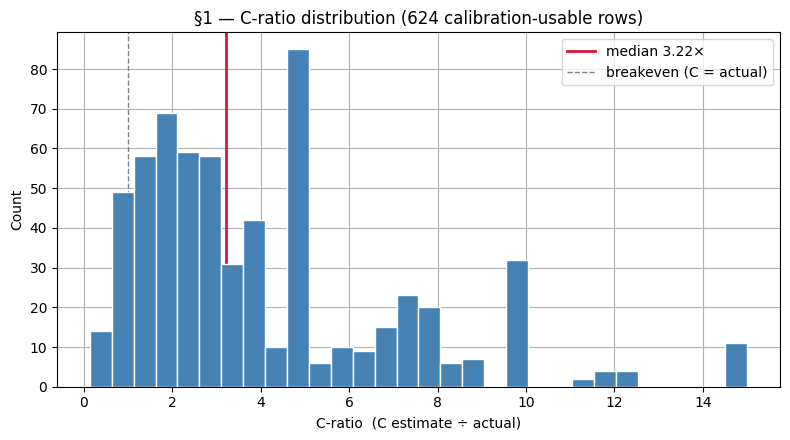

In [5]:
n = len(cal)
n_over = int((cal["c_ratio"] > 1).sum())
bt = stats.binomtest(n_over, n, 0.5, alternative="greater")

lo, hi = bootstrap_ci(cal["c_ratio"])
med = cal["c_ratio"].median()

print(f"Calibration rows   : {n}")
print(f"Ran faster than C  : {n_over}/{n}  ({100*n_over/n:.1f}%)")
print(f"Sign-test p-value  : {bt.pvalue:.2e}")
print(f"Median C-ratio     : {med:.2f}×  [95% CI {lo:.2f}–{hi:.2f}]")
print()
print("Day-7 baseline     : 408/439 (92.9%), median 3.50× [3.12–3.92]")

fig, ax = plt.subplots()
ax.hist(cal["c_ratio"].clip(upper=15), bins=30, color="steelblue", edgecolor="white", zorder=3)
ax.axvline(med, color="crimson", lw=2, label=f"median {med:.2f}×")
ax.axvline(1.0, color="grey", lw=1, ls="--", label="breakeven (C = actual)")
ax.set_xlabel("C-ratio  (C estimate ÷ actual)")
ax.set_ylabel("Count")
ax.set_title(f"§1 — C-ratio distribution ({n} calibration-usable rows)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. 🆕 Per-day calibration drift — extended window (addresses #208)

Day-seven found a **non-monotone** pattern across 7 days (2.51× → 5.00× → 3.34× → 2.67× → 3.33× → 5.00× → 4.00×) with no statistically significant learning curve. Day-nine adds 06-04 and 06-05 buckets and re-tests.

       day   n  median   lo   hi
2026-05-28  36    2.51 2.21 3.11
2026-05-29  32    5.00 3.00 7.50
2026-05-30  38    3.34 2.76 4.22
2026-05-31  53    2.67 2.50 5.00
2026-06-01 117    3.33 3.00 3.75
2026-06-02  40    5.00 3.50 5.50
2026-06-03 143    4.00 3.33 5.00
2026-06-04 109    2.50 2.00 3.00
2026-06-05  56    3.33 2.25 5.00

Spearman ρ = -0.084,  p = 0.830  (n_days = 9)
→ No statistically significant monotone trend detected (p ≥ 0.05).
  ⚠ Underpowered: with only 9 day-buckets, Spearman has ~5% power to detect
  anything short of a perfect monotone. Result is uninformative — not a negative
  finding. Revisit when n_days ≥ 10.


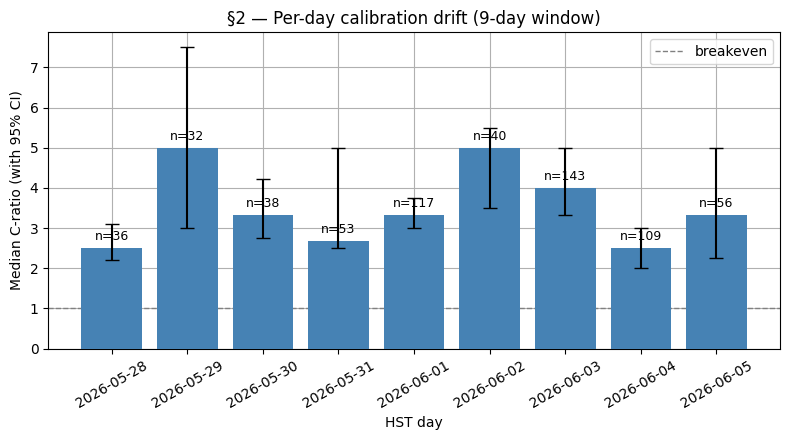

In [6]:
day_rows = []
for d, g in cal.groupby("hst_day"):
    cr = g["c_ratio"].values
    if len(cr) < 2:
        continue
    med_d = np.median(cr)
    lo_d, hi_d = bootstrap_ci(cr, n=5_000)
    day_rows.append({"day": str(d), "n": len(cr), "median": med_d, "lo": lo_d, "hi": hi_d})

day_df = pd.DataFrame(day_rows).sort_values("day").reset_index(drop=True)
print(day_df[["day", "n", "median", "lo", "hi"]].to_string(index=False, float_format="{:.2f}".format))

sp = stats.spearmanr(range(len(day_df)), day_df["median"])
n_days = len(day_df)
print(f"\nSpearman ρ = {sp.statistic:.3f},  p = {sp.pvalue:.3f}  (n_days = {n_days})")
if sp.pvalue < 0.05:
    print("→ Statistically significant monotone trend.")
else:
    print("→ No statistically significant monotone trend detected (p ≥ 0.05).")
    print(f"  ⚠ Underpowered: with only {n_days} day-buckets, Spearman has ~5% power to detect")
    print("  anything short of a perfect monotone. Result is uninformative — not a negative")
    print("  finding. Revisit when n_days ≥ 10.")

fig, ax = plt.subplots()
ax.bar(day_df["day"], day_df["median"], color="steelblue", zorder=3)
ax.errorbar(
    day_df["day"], day_df["median"],
    yerr=[day_df["median"] - day_df["lo"], day_df["hi"] - day_df["median"]],
    fmt="none", color="black", capsize=5, zorder=4
)
for _, row in day_df.iterrows():
    ax.text(row["day"], row["median"] + 0.2, f'n={row["n"]}', ha="center", fontsize=9)
ax.axhline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("HST day")
ax.set_ylabel("Median C-ratio (with 95% CI)")
ax.set_title(f"§2 — Per-day calibration drift ({n_days}-day window)")
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Role-by-day composition check — does task mix vary enough to confound the drift claim?
role_day = (cal.groupby("hst_day")["role"]
              .value_counts()
              .unstack(fill_value=0)
              .reindex(sorted(cal["hst_day"].dropna().unique())))
display(role_day.style
        .set_caption("§2 — Role composition per day (calibration-usable rows)")
        .background_gradient(axis=None, cmap="Blues"))
print("Composition note: if high-ratio roles (RESEARCH, SPIKE, TEST) dominate a given day,")
print("the per-day median reflects mix, not time-based drift.")

role,ARC,CHORE,COMBO,DATA,DEV,PM,RESEARCH,REVIEW,SPIKE,TEST,WRITER
hst_day,,,,,,,,,,,
2026-05-28,4,0,1,0,16,0,0,0,0,1,14
2026-05-29,0,0,1,2,4,0,3,0,4,9,9
2026-05-30,1,0,2,1,10,5,10,0,0,5,4
2026-05-31,0,0,0,6,8,9,7,0,0,1,22
2026-06-01,6,3,2,11,43,1,29,0,2,0,20
2026-06-02,2,0,2,1,10,0,8,1,0,0,16
2026-06-03,5,2,0,9,59,7,29,1,0,1,30
2026-06-04,0,1,1,5,38,11,14,2,4,7,26
2026-06-05,2,0,0,0,13,8,12,0,3,0,18


Composition note: if high-ratio roles (RESEARCH, SPIKE, TEST) dominate a given day,
the per-day median reflects mix, not time-based drift.


**Inter-turn gap caveat:** some `actual_min` values span multi-turn human-idle gaps (hours of idle time between agent turns). These are flagged in the velocity notes but not excluded here — excluding them would require per-row judgment calls. Treat per-day medians as upper bounds on true agent wall-clock.

**05-29 CI anomaly:** day 05-29 showed an unusually wide bootstrap CI [3.17–6.88] in day-five. This remains a caution flag: either a few extreme-ratio outliers, longer inter-turn idle gaps, or genuine within-day volatility. Treat the 05-29 median as less reliable than other buckets.

## 3. Per-agent calibration — re-run on full dataset

Day-seven finding: agents differ but **Kruskal-Wallis went non-significant** (H = 5.35, p = 0.618) — agent medians broadly stable. Re-running with 06-04 and 06-05 data; all agents expected to grow.

      agent   n  median
     banana   1    0.80
DRAGONFRUIT  82    2.50
      GRAPE  37    2.67
     CHERRY 103    2.86
        FIG  66    3.17
     BANANA  97    3.33
      APPLE 104    3.71
 ELDERBERRY  95    4.17

Kruskal-Wallis (agents n≥2, 7 groups): H = 13.66,  p = 0.0337


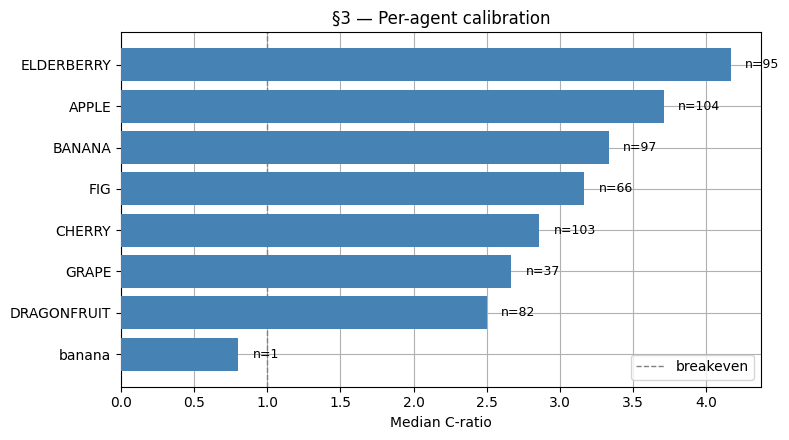

In [8]:
ag = cal[cal["agent"] != ""].copy()

agent_rows = []
for a, g in ag.groupby("agent"):
    cr = g["c_ratio"].values
    agent_rows.append({"agent": a, "n": len(cr), "median": np.median(cr)})
agent_df = pd.DataFrame(agent_rows).sort_values("median")
print(agent_df.to_string(index=False, float_format="{:.2f}".format))

# Exclude singletons (n=1) from KW
kw_agents = agent_df[agent_df["n"] >= 2]["agent"]
groups = [ag[ag["agent"] == a]["c_ratio"].values for a in kw_agents]
agent_kw = stats.kruskal(*groups)
print(f"\nKruskal-Wallis (agents n≥2, {len(kw_agents)} groups): H = {agent_kw.statistic:.2f},  p = {agent_kw.pvalue:.4f}")

fig, ax = plt.subplots()
ax.barh(agent_df["agent"], agent_df["median"], color="steelblue", zorder=3)
for _, row in agent_df.iterrows():
    ax.text(row["median"] + 0.1, row["agent"], f'n={row["n"]}', va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("Median C-ratio")
ax.set_title("§3 — Per-agent calibration")
ax.legend()
plt.tight_layout()
plt.show()

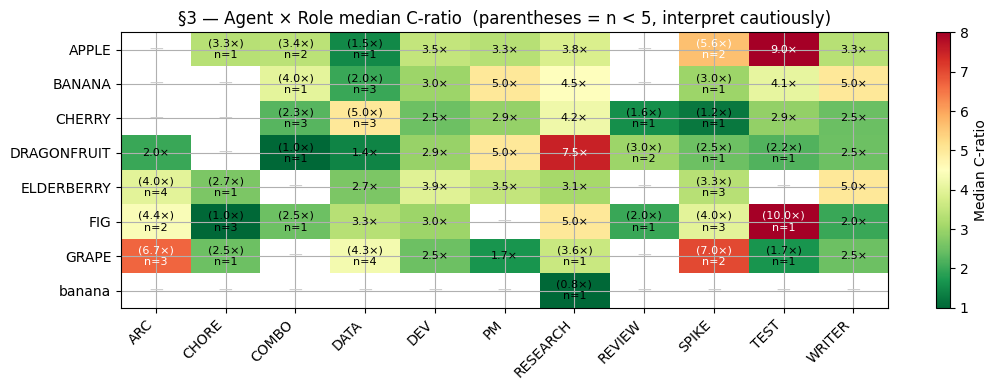

In [9]:
# Agent × Role heatmap — de-confound the per-agent spread
pivot_med   = ag.pivot_table(values="c_ratio", index="agent", columns="role", aggfunc="median")
pivot_count = ag.pivot_table(values="c_ratio", index="agent", columns="role", aggfunc="count")

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(pivot_med.values, aspect="auto", cmap="RdYlGn_r", vmin=1, vmax=8)
ax.set_xticks(range(len(pivot_med.columns)))
ax.set_xticklabels(pivot_med.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_med.index)))
ax.set_yticklabels(pivot_med.index)

for i in range(len(pivot_med.index)):
    for j in range(len(pivot_med.columns)):
        v = pivot_med.values[i, j]
        nc = pivot_count.values[i, j]
        if not np.isnan(v):
            label = f"{v:.1f}×" if nc >= 5 else f"({v:.1f}×)\nn={int(nc)}"
            ax.text(j, i, label, ha="center", va="center", fontsize=8,
                    color="white" if v > 5 else "black")
        else:
            ax.text(j, i, "—", ha="center", va="center", fontsize=10, color="#cccccc")

plt.colorbar(im, ax=ax, label="Median C-ratio")
ax.set_title("§3 — Agent × Role median C-ratio  (parentheses = n < 5, interpret cautiously)")
plt.tight_layout()
plt.show()

## 4. Per-role calibration — all roles

Extended role vocab (DATA, ARC, COMBO, SPIKE) kept as-is. Cells with n ≤ 6 are flagged — treat as directional only.

    role   n  median  small_n
    TEST  24    4.55    False
     ARC  20    4.25    False
RESEARCH 112    4.00    False
   SPIKE  13    4.00    False
   COMBO   9    3.33    False
  WRITER 159    3.00    False
      PM  41    3.00    False
     DEV 201    2.86    False
    DATA  35    2.00    False
   CHORE   6    1.88     True
  REVIEW   4    1.80     True


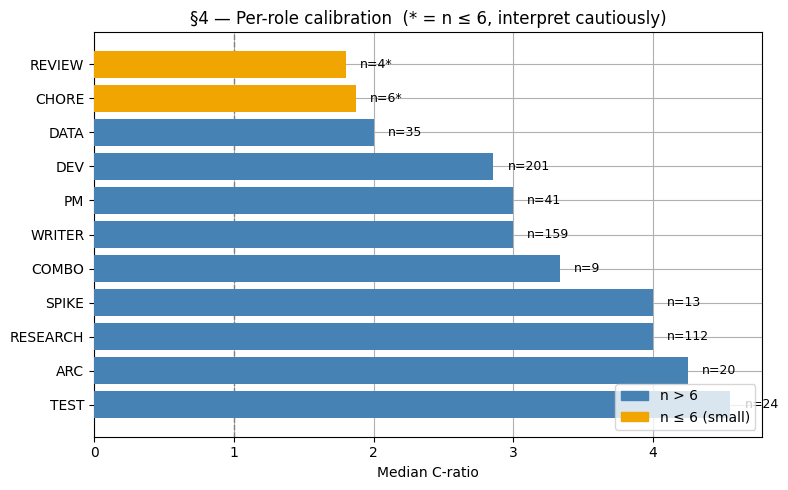

In [10]:
role_rows = []
for r, g in cal.groupby("role"):
    cr = g["c_ratio"].values
    role_rows.append({"role": r, "n": len(cr), "median": np.median(cr)})
role_df = pd.DataFrame(role_rows).sort_values("median", ascending=False)
role_df["small_n"] = role_df["n"] <= 6
print(role_df[["role", "n", "median", "small_n"]].to_string(index=False, float_format="{:.2f}".format))

from matplotlib.patches import Patch
colors = ["#f0a500" if row.small_n else "steelblue" for _, row in role_df.iterrows()]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(role_df["role"], role_df["median"], color=colors, zorder=3)
for _, row in role_df.iterrows():
    label = f'n={row["n"]}' + ("*" if row.small_n else "")
    ax.text(row["median"] + 0.1, row["role"], label, va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1)
ax.set_xlabel("Median C-ratio")
ax.set_title("§4 — Per-role calibration  (* = n ≤ 6, interpret cautiously)")
ax.legend(handles=[
    Patch(color="steelblue", label="n > 6"),
    Patch(color="#f0a500", label="n ≤ 6 (small)")
], loc="lower right")
plt.tight_layout()
plt.show()

## 5. Model-stratified calibration

Rows with a populated `model` column split below; only calibration-usable rows included. Day-seven: sonnet-4.6 n=316, 3.88×; opus-4.8 n=16, 2.50×. Checking whether opus-4.8 has crossed n ≥ 20 and whether the directional gap persists.

Calibration-usable rows with model: 517
model
sonnet-4.6    501
opus-4.8       16

      model   n  median
sonnet-4.6 501    3.33
  opus-4.8  16    2.50

Kruskal-Wallis (models with n≥2): H = 1.63,  p = 0.2017
CAVEAT: n is small — result is preliminary.


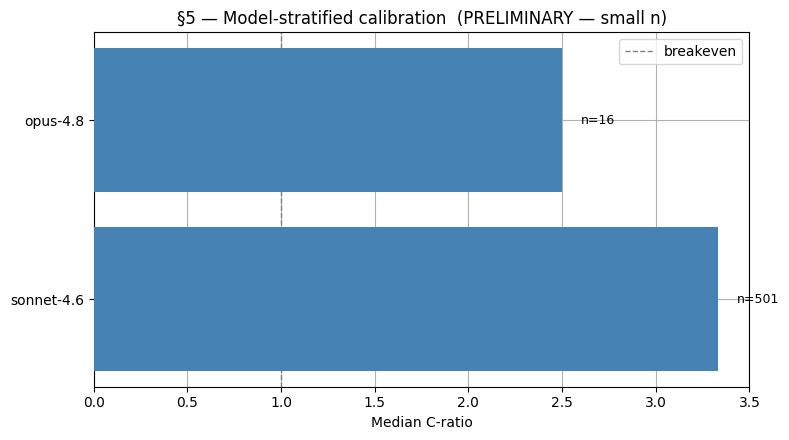

In [11]:
mod = cal[cal["model"].notna() & (cal["model"] != "")].copy()
print(f"Calibration-usable rows with model: {len(mod)}")
print(mod["model"].value_counts().to_string())

mod_rows = []
for m, g in mod.groupby("model"):
    cr = g["c_ratio"].values
    mod_rows.append({"model": m, "n": len(cr), "median": np.median(cr)})
mod_df = pd.DataFrame(mod_rows).sort_values("median", ascending=False)
print("\n", mod_df.to_string(index=False, float_format="{:.2f}".format))

kw_groups = [
    mod[mod["model"] == m]["c_ratio"].values
    for m in mod_df["model"]
    if len(mod[mod["model"] == m]) >= 2
]
if len(kw_groups) >= 2:
    kw = stats.kruskal(*kw_groups)
    print(f"\nKruskal-Wallis (models with n≥2): H = {kw.statistic:.2f},  p = {kw.pvalue:.4f}")
    print("CAVEAT: n is small — result is preliminary.")

SINGLE_POINT = {"haiku-4.5"}
fig, ax = plt.subplots()
ax.barh(mod_df["model"], mod_df["median"], color="steelblue", zorder=3)
for _, row in mod_df.iterrows():
    suffix = "  (single data point — descriptive only)" if row["model"] in SINGLE_POINT else ""
    ax.text(row["median"] + 0.1, row["model"], f'n={row["n"]}{suffix}', va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("Median C-ratio")
ax.set_title("§5 — Model-stratified calibration  (PRELIMINARY — small n)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. 🆕 ELDERBERRY task-mix drill-down (carried from day-seven)

Day-seven confirmed ELDERBERRY at 5.00× overall — the highest-median agent. Re-running on the expanded dataset with 06-04 and 06-05 data. Key question: **does ELDERBERRY's high median persist within roles, or is it role-composition driven?** Day-seven also flagged a RESEARCH reversal (EB 3.88 < fleet 4.76) — checking if that holds.

In [12]:
eb = ag[ag["agent"] == "ELDERBERRY"].copy()
print(f"ELDERBERRY calibration-usable rows: {len(eb)}")
print()

# Role distribution for ELDERBERRY vs. fleet
eb_role = eb["role"].value_counts().rename("ELDERBERRY")
fleet_role = ag[ag["agent"] != "ELDERBERRY"]["role"].value_counts().rename("Fleet (others)")
role_compare = pd.concat([eb_role, fleet_role], axis=1).fillna(0).astype(int)
role_compare["EB_pct"]    = (role_compare["ELDERBERRY"]    / role_compare["ELDERBERRY"].sum()    * 100).round(1)
role_compare["Fleet_pct"] = (role_compare["Fleet (others)"] / role_compare["Fleet (others)"].sum() * 100).round(1)
display(role_compare.style.set_caption("§6 — ELDERBERRY vs. fleet role distribution").background_gradient(axis=None, cmap="Blues", subset=["ELDERBERRY", "Fleet (others)"]))

print()

# Per-role median + Mann-Whitney U tests for ELDERBERRY vs. fleet
within_rows = []
for role in sorted(eb["role"].unique()):
    eb_cr = eb[eb["role"] == role]["c_ratio"].values
    fleet_cr = ag[(ag["agent"] != "ELDERBERRY") & (ag["role"] == role)]["c_ratio"].values
    row = {
        "role": role,
        "EB_n": len(eb_cr),
        "EB_median": round(np.median(eb_cr), 2) if len(eb_cr) else None,
        "Fleet_n": len(fleet_cr),
        "Fleet_median": round(np.median(fleet_cr), 2) if len(fleet_cr) else None,
        "U": None, "p_mwu": None, "underpowered": None,
    }
    if len(eb_cr) >= 2 and len(fleet_cr) >= 2:
        u_stat, p_val = stats.mannwhitneyu(eb_cr, fleet_cr, alternative="two-sided")
        row["U"] = round(u_stat, 1)
        row["p_mwu"] = round(p_val, 4)
        row["underpowered"] = (len(eb_cr) < 5) or (len(fleet_cr) < 5)
    else:
        row["underpowered"] = True
    within_rows.append(row)
within_df = pd.DataFrame(within_rows)
print(within_df[["role","EB_n","EB_median","Fleet_n","Fleet_median","U","p_mwu","underpowered"]].to_string(index=False))
print()
print("Note: underpowered = n < 5 in either group; U-test omitted for singletons.")

print()
print(f"ELDERBERRY overall median: {np.median(eb['c_ratio'].values):.2f}×")
fleet_all = ag[ag['agent'] != 'ELDERBERRY']['c_ratio']
print(f"Fleet overall median:      {np.median(fleet_all.values):.2f}×")

ELDERBERRY calibration-usable rows: 95



,ELDERBERRY,Fleet (others),EB_pct,Fleet_pct
role,,,,
WRITER,33,109,34.700000,22.200000
RESEARCH,21,91,22.100000,18.600000
DEV,18,167,18.900000,34.100000
DATA,9,26,9.500000,5.300000
PM,6,35,6.300000,7.100000
ARC,4,12,4.200000,2.400000
SPIKE,3,10,3.200000,2.000000
CHORE,1,5,1.100000,1.000000
TEST,0,23,0.000000,4.700000



    role  EB_n  EB_median  Fleet_n  Fleet_median      U  p_mwu  underpowered
     ARC     4       4.00       12          4.79   28.5 0.6264          True
   CHORE     1       2.67        5          1.25    NaN    NaN          True
    DATA     9       2.67       26          1.91  153.5 0.1732         False
     DEV    18       3.93      167          2.86 1777.5 0.2035         False
      PM     6       3.50       35          3.00  121.5 0.5540         False
RESEARCH    21       3.12       91          4.29  766.0 0.1584         False
   SPIKE     3       3.33       10          4.00   15.0 1.0000          True
  WRITER    33       5.00      109          2.82 2327.5 0.0104         False

Note: underpowered = n < 5 in either group; U-test omitted for singletons.

ELDERBERRY overall median: 4.17×
Fleet overall median:      3.12×


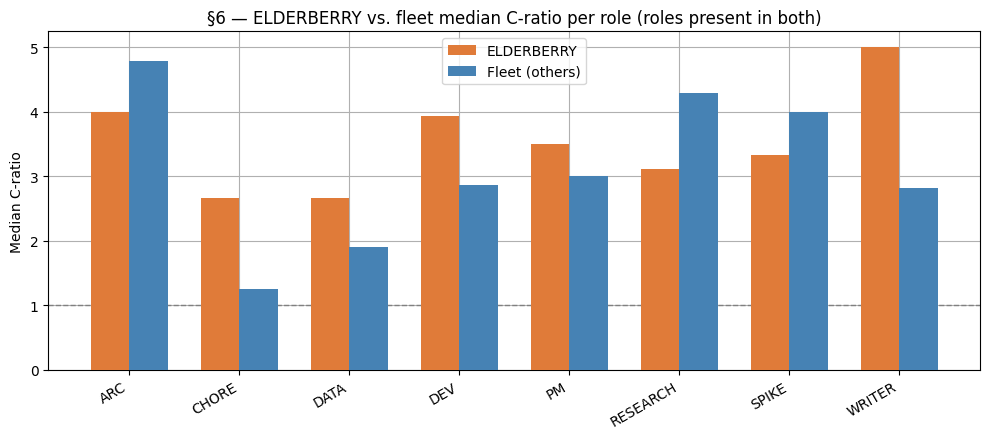

In [13]:
# Side-by-side bar: ELDERBERRY vs. fleet median per role
plot_df = within_df.dropna(subset=["EB_median", "Fleet_median"])
if len(plot_df) > 0:
    x = np.arange(len(plot_df))
    w = 0.35
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(x - w/2, plot_df["EB_median"],    w, label="ELDERBERRY", color="#e07b39", zorder=3)
    ax.bar(x + w/2, plot_df["Fleet_median"], w, label="Fleet (others)", color="steelblue", zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["role"], rotation=30, ha="right")
    ax.axhline(1.0, color="grey", ls="--", lw=1)
    ax.set_ylabel("Median C-ratio")
    ax.set_title("§6 — ELDERBERRY vs. fleet median C-ratio per role (roles present in both)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No roles with data in both ELDERBERRY and fleet — skipping comparison plot.")

## 7. Takeaways — day nine

### What we can now say

**§1 — Core finding holds at 624 rows.**
Re-run on **624 calibration-usable rows**: **566/624 (90.7%)** ran faster than the C-estimate
(sign-test p = 5.84×10⁻¹⁰⁶). Median C-ratio **3.22× [95% CI 3.00–3.57]**. Day-seven baseline was
408/439 (92.9%), 3.50× [3.12–3.92] — hit-rate ticked down slightly and median dipped from 3.50
to 3.22, consistent with more DATA/DEV tasks at lower ratios entering the corpus. CIs still
overlap. Core finding remains robust.

**§2 — Per-day drift: 9-day window, still no signal (#208).**
Nine day-buckets (05-28 through 06-05): **2.51× → 5.00× → 3.34× → 2.67× → 3.33× → 5.00× →
4.00× → 2.50× → 3.33×**.
Spearman ρ = −0.084, p = 0.830 — pattern remains non-monotone, non-significant.
06-04 (n=109, 2.50×) is a notably low-ratio day — the second lowest median in the set.
06-05 (n=56, 3.33×) is broadly consistent with the overall median.
Now at n_days = 9, one day away from the n_days ≥ 10 threshold for the Spearman re-test.

> Inter-turn gap caveat: `actual_min` for multi-turn tasks includes human-idle time; per-day
> medians are upper bounds on true agent wall-clock.

**§3 — 🆕 Agent KW NOW SIGNIFICANT; DRAGONFRUIT drops to lowest; ELDERBERRY remains highest.**
Kruskal-Wallis across 7 groups (n≥2): **H = 13.66, p = 0.034** — significant for the first time.
Agent medians (day-nine, ascending): DRAGONFRUIT 2.50× (n=82) · GRAPE 2.67× (n=37) · CHERRY
2.86× (n=103) · FIG 3.17× (n=66) · BANANA 3.33× (n=97) · APPLE 3.71× (n=104) · ELDERBERRY
4.17× (n=95).

Notes:
- **KW significance** — with more rows, inter-agent differences now cross α=0.05. Post-hoc
  pairwise analysis (MWU) warranted in a future pass to identify which agent pairs drive the
  signal.
- **GRAPE** grew from n=2 to n=37 — no longer directional only; now a full contributor to KW.
- **"fig" casing anomaly** (day-seven: n=4 at 4.38×) is absent — rows appear normalized into
  FIG (n=66, up from n=41+4=45). Effective fix in place.
- **"banana" casing anomaly** — 1 row logged as "banana" (0.80×) instead of "BANANA"; excluded
  from KW (singleton). Needs DB correction (Rule 7 — requires explicit permission).
- **DRAGONFRUIT** dropped from 2.82× to 2.50×, now the best-calibrated agent.

**§4 — Role ordering: ARC rose; WRITER and REVIEW fell.**
Full order: TEST 4.55× · ARC 4.25× · RESEARCH 4.00× · SPIKE 4.00× · COMBO 3.33× · WRITER
3.00× · PM 3.00× · DEV 2.86× · DATA 2.00× · CHORE 1.88× · REVIEW 1.80×.
Notable shifts from day-seven: ARC rose (3.46 → 4.25×, n=20); WRITER fell (3.60 → 3.00×);
RESEARCH fell (4.29 → 4.00×); DEV fell (3.28 → 2.86×); DATA fell (2.43 → 2.00×); TEST fell
slightly (5.06 → 4.55×). REVIEW is small-n (n=4) — treat as unstable.

**§5 — Model: sonnet median fell; opus-4.8 still stuck at n=16.**
sonnet-4.6: n=501, 3.33× (down from 3.88×). opus-4.8: n=16, 2.50× (unchanged — no new opus
rows since day-seven). KW H=1.63, p=0.202 — gap is no longer even approaching significance.
The directional gap persists (opus faster relative to estimates) but the sonnet sample grew
substantially and its median drifted down toward opus. opus-4.8 remains 4+ tasks short of
n=20; revisit when it grows.

**§6 — ELDERBERRY drill-down re-run: overall median fell; WRITER gap widened; RESEARCH reversal persists.**
ELDERBERRY overall 4.17× (down from 5.00×) vs. fleet 3.12× (down from 3.48×). Within-role:
- WRITER: EB 5.00× (n=33) vs. fleet 2.82× — gap **widened** from day-seven (5.00 vs. 3.10→2.82)
- DEV: EB 3.93× (n=18) vs. fleet 2.86×
- RESEARCH: EB 3.12× (n=21) vs. fleet 4.29× — **RESEARCH reversal persists**: EB remains
  better-calibrated on RESEARCH for the second run. Likely a genuine pattern, not noise.
- DATA: EB 2.67× (n=9) vs. fleet 1.91× — fleet pulled ahead on DATA calibration
- ARC: EB 4.00× (n=4) vs. fleet 4.79× — underpowered; EB lower
- SPIKE: EB 3.33× (n=3) vs. fleet 4.00× — underpowered

Conclusion: ELDERBERRY's overall median fell (5.00→4.17×) but remains the highest agent. The
WRITER over-estimation gap is the dominant driver (5.00× vs. fleet 2.82×). The RESEARCH reversal
is now confirmed across two runs — ELDERBERRY is genuinely better-calibrated on RESEARCH tasks.

---

### Deferred

- **Agent post-hoc MWU** — KW is significant (p=0.034); next step is pairwise MWU to identify
  which agent pairs are significantly different. Defer to a future pass.
- **Git-churn / lead-time enrichment** — defer until DB-native enrichment lands (per #288).
- **Model-stratified analysis** — revisit when opus-4.8 reaches n ≥ 20 (currently n=16; 4+ tasks away).
- **Model-naming violations** — `claude-sonnet-4-6` still needs DB re-normalization; skill template fix pending.
- **"banana" casing anomaly** — 1 row with agent="banana"; needs DB correction (Rule 7 — explicit permission required).
- **Per-day drift** — re-test Spearman when n_days ≥ 10 (currently 9; one more working day away).
- **ELDERBERRY WRITER gap** — monitor in future runs: the 5.00× vs. 2.82× gap is now the
  starkest inter-agent within-role difference.

---

*This notebook supersedes day-seven for all calibration findings.*
*Cross-references: #208 (over-time drift), #288 (enrich.py retirement), #516 (day-six run), #667 (day-seven run), #885 (this run).*

In [14]:
# Summary printout — fills in the takeaways narrative automatically
n_total = len(df)
n_cal   = len(cal)
med_all = cal["c_ratio"].median()
lo_all, hi_all = bootstrap_ci(cal["c_ratio"])
n_over_all = int((cal["c_ratio"] > 1).sum())
bt_all = stats.binomtest(n_over_all, n_cal, 0.5, alternative="greater")

print("=== Day-nine summary ===")
print(f"Total rows      : {n_total}  (day-7 was 534)")
print(f"Cal-usable      : {n_cal}  (day-7 was 439)")
print(f"Faster than C   : {n_over_all}/{n_cal} ({100*n_over_all/n_cal:.1f}%)")
print(f"Median C-ratio  : {med_all:.2f}× [{lo_all:.2f}–{hi_all:.2f}]")
print(f"Sign-test p     : {bt_all.pvalue:.2e}")
print()
print("Per-day pattern :")
for _, row in day_df.iterrows():
    print(f"  {row['day']}  n={row['n']:3d}  median={row['median']:.2f}×")
print(f"Spearman ρ={sp.statistic:.3f}, p={sp.pvalue:.3f}")
print()
print("Agent medians (day-nine):")
for _, row in agent_df.sort_values("median").iterrows():
    print(f"  {row['agent']:15s} {row['median']:.2f}×  n={row['n']}")
print(f"KW H={agent_kw.statistic:.2f}, p={agent_kw.pvalue:.4f}")
print()
print("ELDERBERRY drill-down:")
print(f"  EB overall median : {np.median(eb['c_ratio'].values):.2f}×  n={len(eb)}")
print(f"  Fleet median      : {np.median(fleet_all.values):.2f}×  n={len(fleet_all)}")

=== Day-nine summary ===
Total rows      : 684  (day-7 was 534)
Cal-usable      : 624  (day-7 was 439)
Faster than C   : 566/624 (90.7%)
Median C-ratio  : 3.22× [3.00–3.57]
Sign-test p     : 5.84e-106

Per-day pattern :
  2026-05-28  n= 36  median=2.51×
  2026-05-29  n= 32  median=5.00×
  2026-05-30  n= 38  median=3.34×
  2026-05-31  n= 53  median=2.67×
  2026-06-01  n=117  median=3.33×
  2026-06-02  n= 40  median=5.00×
  2026-06-03  n=143  median=4.00×
  2026-06-04  n=109  median=2.50×
  2026-06-05  n= 56  median=3.33×
Spearman ρ=-0.084, p=0.830

Agent medians (day-nine):
  banana          0.80×  n=1
  DRAGONFRUIT     2.50×  n=82
  GRAPE           2.67×  n=37
  CHERRY          2.86×  n=103
  FIG             3.17×  n=66
  BANANA          3.33×  n=97
  APPLE           3.71×  n=104
  ELDERBERRY      4.17×  n=95
KW H=13.66, p=0.0337

ELDERBERRY drill-down:
  EB overall median : 4.17×  n=95
  Fleet median      : 3.12×  n=490


## 8. 🆕 Errors table — first look

New data source: the `errors` table in `~/.lccjs/lccjs.db` (also exported to `stats/errors.csv` via `npm run errors:export`). Tracks agent errors logged via `npm run error:log` — types include `CLAIM_FAIL`, `GIT_FAIL`, `BASH_FAIL`, `TOOL_DENIED`, `OTHER`. Schema in `docs/errors-schema.md`.

**No statistical conclusions are drawn here — the corpus is nascent (all rows from a single day). This section establishes the loading pattern and schema familiarity.**

In [ ]:
# Load errors table from SQLite (same DB as velocity)
con_err = sqlite3.connect(DB)
err_df  = pd.read_sql("SELECT * FROM errors ORDER BY id", con_err)
con_err.close()

print(f"Errors table rows: {len(err_df)}")
print()

# Normalize timezone suffix (same pattern as velocity load above)
err_df["occurred_iso"] = err_df["occurred_iso"].str.replace(r"([+-]\d{2})(\d{2})$", r"\1:\2", regex=True)
err_df["occurred_dt"]  = pd.to_datetime(err_df["occurred_iso"], errors="coerce", utc=True)
err_df["hst_day"]      = err_df["occurred_dt"].dt.tz_convert("Etc/GMT+10").dt.date.astype(str)

# Distributions
type_ct  = err_df["error_type"].fillna("(none)").value_counts().rename_axis("error_type").reset_index(name="n")
agent_ct = err_df["agent"].fillna("(none)").value_counts().rename_axis("agent").reset_index(name="n")
model_ct = err_df["model"].fillna("(none)").value_counts().rename_axis("model").reset_index(name="n")

display(type_ct.style.set_caption("§8 — Error type distribution").hide(axis="index"))
display(agent_ct.style.set_caption("§8 — Errors by agent").hide(axis="index"))
display(model_ct.style.set_caption("§8 — Errors by model").hide(axis="index"))

# Bar: error_type counts
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(type_ct["error_type"], type_ct["n"], color="steelblue", zorder=3)
for i, v in enumerate(type_ct["n"]):
    ax.text(v + 0.05, i, str(v), va="center", fontsize=9)
ax.set_xlabel("Count")
days_in_corpus = err_df["hst_day"].nunique()
ax.set_title(f"§8 — Error type distribution  (n={len(err_df)} rows, {days_in_corpus} day(s) of data)")
plt.tight_layout()
plt.show()

print(f"\nAll errors are from: {sorted(err_df['hst_day'].unique())}")
print("Corpus is nascent — distributions will stabilise as errors accumulate across sessions.")

## 9. 🆕 RICE scores — priority distribution

Scoring of 41 open issues generated by DRAGONFRUIT in issue #811 (2026-06-05). See `stats/rice-notes.md` for the full rubric and findings. **Key filter: sort on `actionable=Y` before using RICE to pick agent work** — human-gated items dominate the raw top-3 despite being unactionable by agents (cheap decisions that unblock high-reach work inflate their RICE scores).

In [ ]:
# Load RICE scores
rice_csv = Path("rice-scores.csv")
if not rice_csv.exists():
    rice_csv = Path("stats/rice-scores.csv")
rice = pd.read_csv(rice_csv)

n_actionable = (rice["actionable"] == "Y").sum()
n_not        = (rice["actionable"] == "N").sum()
print(f"RICE-scored issues : {len(rice)}  (actionable=Y: {n_actionable}  N: {n_not})")
print()

# Scatter: RICE score vs. Yegor priority, coloured by actionable
fig, ax = plt.subplots(figsize=(8, 5))
for flag, color, label in [("Y", "steelblue", "Actionable"), ("N", "#d65f5f", "Not actionable")]:
    sub = rice[rice["actionable"] == flag]
    ax.scatter(sub["yegor_priority"], sub["rice_score"],
               color=color, alpha=0.75, label=f"{label} (n={len(sub)})", s=60, zorder=3)
ax.set_xlabel("Yegor priority  (0–10)")
ax.set_ylabel("RICE score")
ax.set_title(f"§9 — RICE vs. Yegor priority  ({len(rice)} scored issues)")
ax.legend()
plt.tight_layout()
plt.show()

# Top-10 actionable by RICE
top10 = (rice[rice["actionable"] == "Y"]
         .sort_values("rice_score", ascending=False)
         .head(10)
         [["issue", "title", "type", "rice_score", "yegor_priority"]]
         .reset_index(drop=True))
top10.index += 1
display(top10.style
        .set_caption("§9 — Top 10 agent-actionable issues by RICE score")
        .bar(subset=["rice_score"], color="steelblue", vmin=0)
        .hide(axis="index"))

# Spearman correlation: RICE vs. Yegor priority (actionable issues only)
act = rice[rice["actionable"] == "Y"]
rho, p_val = stats.spearmanr(act["rice_score"], act["yegor_priority"])
print(f"\nSpearman ρ (RICE vs. Yegor, actionable only, n={len(act)}): {rho:.3f},  p={p_val:.4f}")
if p_val < 0.05:
    print("→ Statistically significant alignment between RICE and Yegor for actionable issues.")
else:
    print("→ No significant monotone alignment between RICE and Yegor (p ≥ 0.05).")
    print("  The two frameworks prioritize differently on actionable items — see stats/rice-notes.md §3.")

## 10. 🆕 Issue lifecycle — open/close flow, resolution time, age distribution

Data live from `gh issue list`; C-estimate ratios from the already-loaded `cal` subset.
Source research: [`docs/research/issue-lifecycle-analysis-838.md`](../docs/research/issue-lifecycle-analysis-838.md) (ELDERBERRY + BANANA, 2026-06-05, #838).

> **Live data warning:** `gh issue list` fetches the current state at execution time. The #838 research doc is a point-in-time snapshot (June 1–6); re-execution will reflect the current issue state.

In [ ]:
import json, subprocess
from datetime import datetime, timezone

def parse_dt(s):
    return datetime.fromisoformat(s.replace("Z", "+00:00"))

# Fetch closed issues (limit 500)
result = subprocess.run(
    ["gh", "issue", "list", "--state", "closed", "--limit", "500",
     "--json", "number,createdAt,closedAt,labels"],
    capture_output=True, text=True, check=True
)
closed_issues = json.loads(result.stdout)

# Fetch open issues (limit 200)
result2 = subprocess.run(
    ["gh", "issue", "list", "--state", "open", "--limit", "200",
     "--json", "number,title,createdAt,labels"],
    capture_output=True, text=True, check=True
)
open_issues = json.loads(result2.stdout)

print(f"Closed issues fetched : {len(closed_issues)}")
print(f"Open issues fetched   : {len(open_issues)}")

In [ ]:
# §10a — Daily open/close flow
from collections import defaultdict

open_by_day  = defaultdict(int)
close_by_day = defaultdict(int)

for issue in closed_issues:
    d  = parse_dt(issue["createdAt"]).date().isoformat()
    d2 = parse_dt(issue["closedAt"]).date().isoformat()
    open_by_day[d]   += 1
    close_by_day[d2] += 1

for issue in open_issues:
    d = parse_dt(issue["createdAt"]).date().isoformat()
    open_by_day[d] += 1

all_days = sorted(set(list(open_by_day.keys()) + list(close_by_day.keys())))
flow_rows = []
cumulative = 0
for d in all_days:
    o = open_by_day[d]
    c = close_by_day[d]
    net = o - c
    cumulative += net
    flow_rows.append({"date": d, "opened": o, "closed": c, "net": net, "cumulative_net": cumulative})

flow_df = pd.DataFrame(flow_rows)
display(flow_df.style.set_caption("§10a — Daily issue open/close flow").hide(axis="index"))

# Bar chart: most recent 10 days
recent = flow_df.tail(10).reset_index(drop=True)
xr = np.arange(len(recent))
w  = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(xr - w/2, recent["opened"], w, label="Opened", color="steelblue", zorder=3)
ax.bar(xr + w/2, recent["closed"], w, label="Closed", color="coral", zorder=3)
ax.set_xticks(xr)
ax.set_xticklabels(recent["date"], rotation=30, ha="right")
ax.set_ylabel("Issue count")
ax.set_title("§10a — Daily open/close flow (most recent 10 days)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# §10b — Resolution time distribution (closed issues)
resolution_hours = [
    (parse_dt(i["closedAt"]) - parse_dt(i["createdAt"])).total_seconds() / 3600
    for i in closed_issues
]
res = np.array(resolution_hours)

percentiles = [(50, "Median (p50)"), (90, "p90"), (99, "p99"), (100, "Max")]
print("Resolution time percentiles:")
for pct, label in percentiles:
    print(f"  {label:15s}: {np.percentile(res, pct):.1f} h")
print(f"  {'Mean':15s}: {res.mean():.1f} h")
print()

buckets = [
    ("< 1 h",      res < 1),
    ("1 h – 1 d",  (res >= 1)  & (res < 24)),
    ("1 – 3 days", (res >= 24) & (res < 72)),
    ("3 – 7 days", (res >= 72) & (res < 168)),
    ("> 1 week",   res >= 168),
]
print("Resolution time distribution:")
for label, mask in buckets:
    n_b = int(mask.sum())
    print(f"  {label:12s}: {n_b:4d}  ({100*n_b/len(res):.0f}%)")

fig, ax = plt.subplots()
ax.hist(np.clip(res, 0, 48), bins=30, color="steelblue", edgecolor="white", zorder=3)
ax.axvline(np.median(res), color="crimson", lw=2, label=f"median {np.median(res):.1f} h")
ax.set_xlabel("Resolution time (hours, clipped at 48 h)")
ax.set_ylabel("Count")
ax.set_title(f"§10b — Resolution time histogram  (n={len(res)} closed issues)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# §10c — Resolution time by type label
type_rows = []
for issue in closed_issues:
    hours = (parse_dt(issue["closedAt"]) - parse_dt(issue["createdAt"])).total_seconds() / 3600
    type_labels = [
        lbl["name"] for lbl in issue.get("labels", [])
        if not lbl["name"].startswith("area:") and not lbl["name"].startswith("severity:")
    ]
    label = type_labels[0] if type_labels else "(unlabeled)"
    type_rows.append({"type": label, "hours": hours})

type_res_df = pd.DataFrame(type_rows)
type_stats = (
    type_res_df.groupby("type")["hours"]
    .agg(n="count", median="median", mean="mean",
         p90=lambda x: np.percentile(x, 90))
    .reset_index()
    .sort_values("median")
)
type_stats[["median", "mean", "p90"]] = type_stats[["median", "mean", "p90"]].round(2)
display(type_stats.style.set_caption("§10c — Resolution time by type label (hours)").hide(axis="index"))

fig, ax = plt.subplots(figsize=(8, 4))
subset = type_stats[type_stats["n"] >= 3]
ax.barh(subset["type"], subset["median"], color="steelblue", zorder=3)
for _, row in subset.iterrows():
    ax.text(row["median"] + 0.05, row["type"], f'n={row["n"]}  p90={row["p90"]:.1f}h',
            va="center", fontsize=9)
ax.set_xlabel("Median resolution time (hours)")
ax.set_title("§10c — Median resolution time by type  (types with n≥3)")
plt.tight_layout()
plt.show()

In [ ]:
# §10d — Open issue age distribution with blocked/decision status
now = datetime.now(timezone.utc)
age_rows = []
for issue in open_issues:
    age_days = (now - parse_dt(issue["createdAt"])).total_seconds() / 86400
    labels   = [lbl["name"] for lbl in issue.get("labels", [])]
    blocked  = any("blocked" in l or "decision" in l for l in labels)
    age_rows.append({"number": issue["number"], "age_days": age_days, "blocked": blocked})

age_df = pd.DataFrame(age_rows)
print(f"Open issues: {len(age_df)}")
print()

age_buckets = [
    ("< 1 day",   age_df["age_days"] < 1),
    ("1–7 days",  (age_df["age_days"] >= 1)  & (age_df["age_days"] < 7)),
    ("7–30 days", (age_df["age_days"] >= 7)  & (age_df["age_days"] < 30)),
    ("> 30 days", age_df["age_days"] >= 30),
]
bucket_rows = []
for label, mask in age_buckets:
    sub = age_df[mask]
    n_t = len(sub)
    n_b = int(sub["blocked"].sum())
    bucket_rows.append({
        "age bucket": label,
        "total": n_t,
        "blocked/decision": f"{n_b} ({100*n_b/n_t:.0f}%)" if n_t else "—",
    })
bucket_df = pd.DataFrame(bucket_rows)
display(bucket_df.style.set_caption("§10d — Open issue age distribution").hide(axis="index"))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(bucket_df["age bucket"], bucket_df["total"], color="steelblue", zorder=3)
ax.bar(
    bucket_df["age bucket"],
    [int(b.split(" ")[0]) if b != "—" else 0 for b in bucket_df["blocked/decision"]],
    color="coral", zorder=4, label="Blocked/decision",
)
ax.set_ylabel("Count")
ax.set_title("§10d — Open issue age (steelblue=total, coral=blocked/decision)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# §10e — C-estimate calibration by role (velocity.db, same cal subset as §1–§6)
role_calib_rows = []
for r, g in cal.groupby("role"):
    cr = g["c_ratio"].values
    role_calib_rows.append({
        "role": r,
        "n": len(cr),
        "avg_actual_min": round(g["actual_min"].mean(), 1),
        "avg_c_min": round(g["c_min"].mean(), 1),
        "c_actual_ratio": round(g["c_min"].mean() / g["actual_min"].mean(), 1),
        "pct_on_time": round(100 * (cr >= 1.0).sum() / len(cr), 0),
    })
role_calib_df = (
    pd.DataFrame(role_calib_rows)
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)
display(role_calib_df.style
        .set_caption("§10e — C-estimate calibration by role  (cal subset from velocity.db)")
        .hide(axis="index"))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(role_calib_df["role"], role_calib_df["c_actual_ratio"], color="steelblue", zorder=3)
for _, row in role_calib_df.iterrows():
    ax.text(row["c_actual_ratio"] + 0.05, row["role"],
            f'n={row["n"]}  {row["pct_on_time"]:.0f}% on-time', va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1, label="1× (perfect calibration)")
ax.set_xlabel("avg_c_min / avg_actual_min")
ax.set_title("§10e — C-estimate over-estimation ratio by role\n(>1 = estimated high — finished faster)")
ax.legend()
plt.tight_layout()
plt.show()